In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
# =====================================================
# Load Dataset & Basic Preprocessing
# =====================================================

df = pd.read_csv('../Data/data.csv')

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)   

df['StateHoliday'] = df['StateHoliday'].astype(str)

D:\Temp\ipykernel_18068\985394716.py:5: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data.csv')


In [4]:
print("Total Sales:",df["Sales"].sum())
print("Avg Sales:",df["Sales"].mean())
print("std Sales:",df["Sales"].std())
print("Max Sales:",df["Sales"].max())
print("Min Sales:",df["Sales"].min())

Total Sales: 4483680980
Avg Sales: 5742.206014377028
std Sales: 3852.3109319004266
Max Sales: 38037
Min Sales: 0


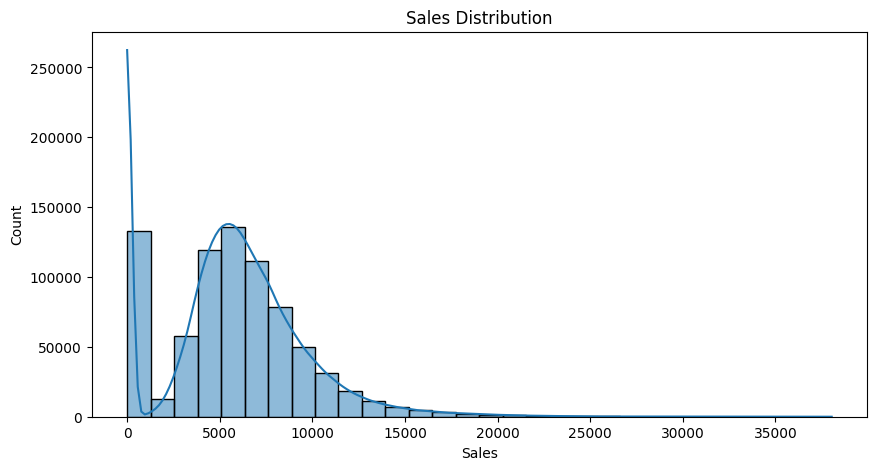

In [5]:
# Sales Distribution:
plt.figure(figsize=(10,5))
sns.histplot(df["Sales"], bins=30, kde=True)
plt.title("Sales Distribution")
plt.show()

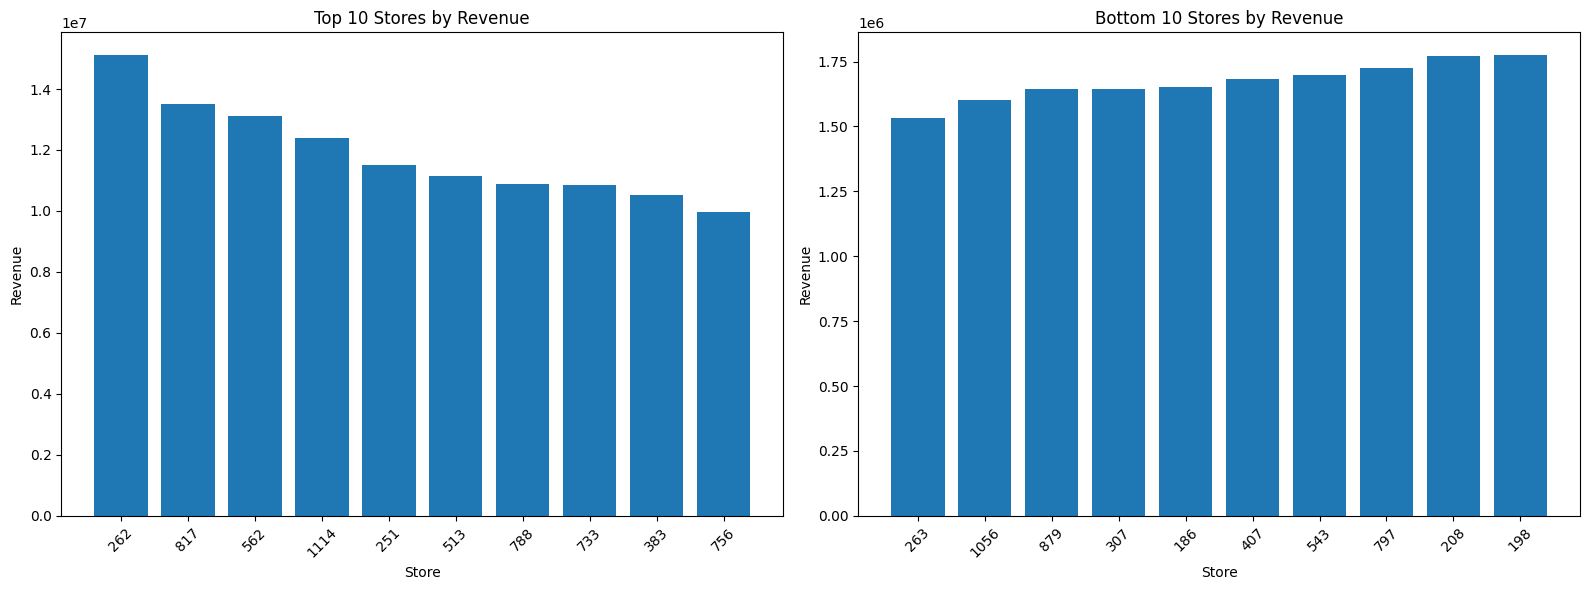

Store
262     15104341
817     13499448
562     13114133
1114    12393510
251     11507641
513     11153247
788     10883902
733     10837089
383     10507197
756      9953504
Name: Sales, dtype: int64
Store
263     1531086
1056    1600361
879     1643497
307     1644823
186     1653309
407     1684038
543     1696567
797     1725472
208     1771534
198     1773796
Name: Sales, dtype: int64


In [6]:
# Top 10 Stores
top10 = df.groupby("Store")["Sales"].sum().sort_values(ascending=False).head(10)

# Bottom 10 Stores
bottom10 =df.groupby("Store")["Sales"].sum().sort_values(ascending=True).head(10)

plt.figure(figsize=(16,6))

# Top 10
plt.subplot(1,2,1)
plt.bar(top10.index.astype(str), top10.values)
plt.title("Top 10 Stores by Revenue")
plt.xlabel("Store")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

# Bottom 10
plt.subplot(1,2,2)
plt.bar(bottom10.index.astype(str), bottom10.values)
plt.title("Bottom 10 Stores by Revenue")
plt.xlabel("Store")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print(top10)
print(bottom10)

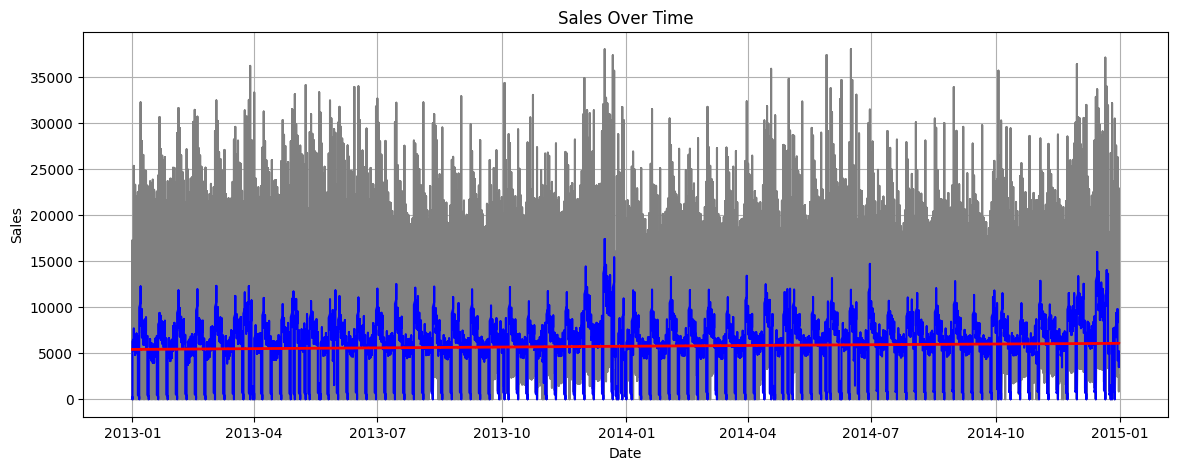

Slope: -0.0008


In [7]:
# Sales Trend:
x = np.arange(len(df))
y = df['Sales'].values
coeffs = np.polyfit(x, y, deg=1)
trend_line = np.polyval(coeffs, x)

df['SMA_7'] = df['Sales'].rolling(window=30).mean()

plt.figure(figsize=(14,5))
plt.plot(df.index, df['Sales'], color='grey')
plt.plot(df['SMA_7'], label='SMA 7-day', color='blue')
plt.plot(df.index, trend_line, label='Trend Line (deg=1)', 
         color='red', linewidth=2)

plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid()
plt.show()

print(f"Slope: {coeffs[0]:.4f}")

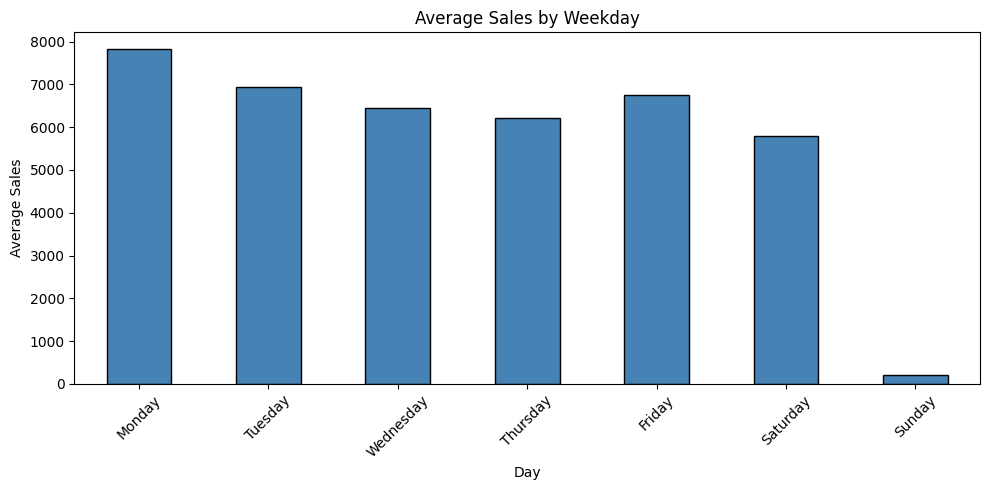

weekday
Monday       7824.475243
Tuesday      6948.371531
Wednesday    6446.173889
Thursday     6221.667389
Friday       6744.443521
Saturday     5792.947996
Sunday        201.323994
Name: Sales, dtype: float64


In [8]:
df['weekday'] = df.index.day_name()

weekday_order = ['Monday','Tuesday','Wednesday',
                 'Thursday','Friday','Saturday','Sunday']

weekday_avg = df.groupby('weekday')['Sales'].mean()
weekday_avg = weekday_avg.reindex(weekday_order)

# Plot
plt.figure(figsize=(10,5))
weekday_avg.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Average Sales by Weekday')
plt.xlabel('Day')
plt.ylabel('Average Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(weekday_avg)
df.drop("weekday", axis=1, inplace=True)

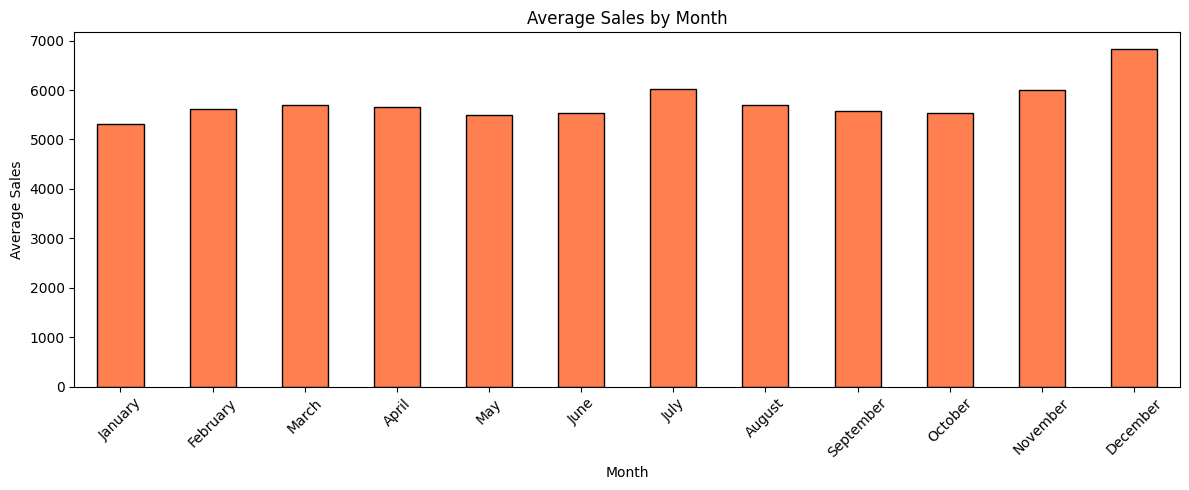

month
January      5321.717282
February     5612.731454
March        5702.303240
April        5649.871584
May          5498.398958
June         5541.844574
July         6022.605649
August       5693.016554
September    5570.246033
October      5537.037419
November     6008.111821
December     6826.611377
Name: Sales, dtype: float64


In [9]:
df['month'] = df.index.month_name()

month_order = ['January','February','March','April',
               'May','June','July','August',
               'September','October','November','December']

month_avg = df.groupby('month')['Sales'].mean()
month_avg = month_avg.reindex(month_order)

plt.figure(figsize=(12,5))
month_avg.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Average Sales by Month')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(month_avg)
df.drop("month", axis=1, inplace=True)

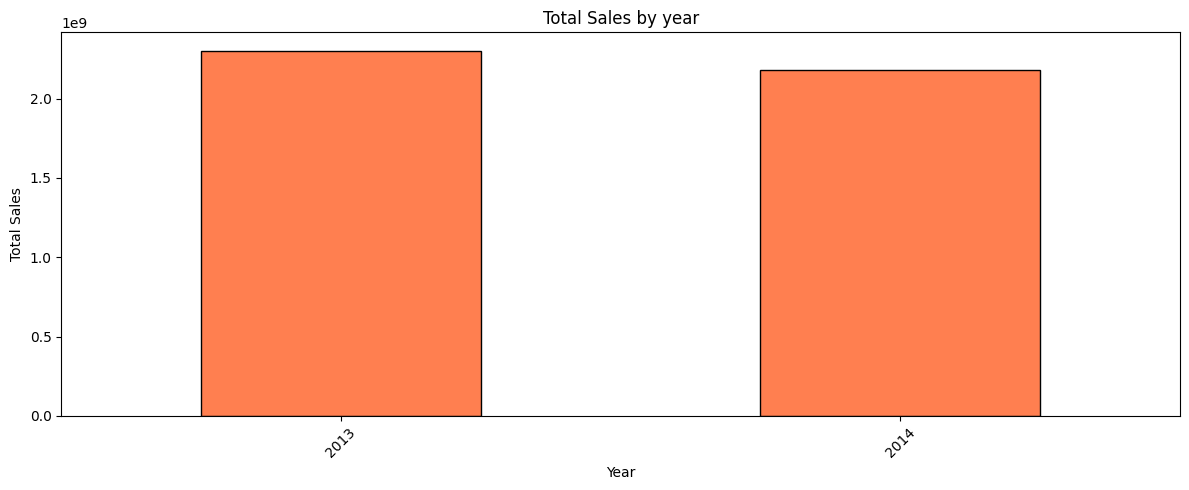

year
2013    2302876084
2014    2180804896
Name: Sales, dtype: int64


In [10]:
df['year'] = df.index.year

year_revenue = df.groupby('year')['Sales'].sum()

plt.figure(figsize=(12,5))
year_revenue.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Total Sales by year')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(year_revenue)
df.drop("year", axis=1, inplace=True)

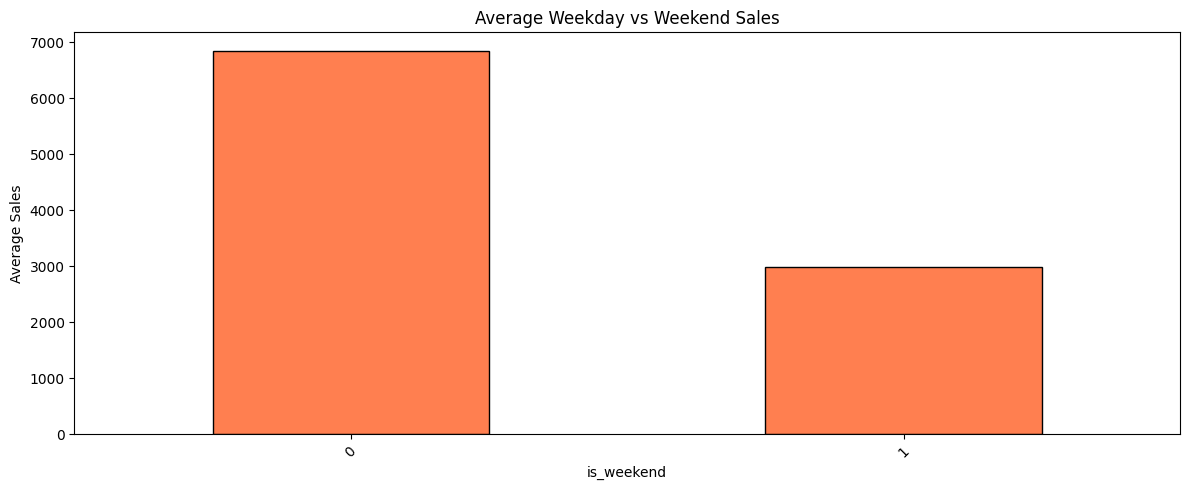

is_weekend
0    6836.557991
1    2997.135995
Name: Sales, dtype: float64


In [11]:
df["day_of_week"] = df.index.day_of_week
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

weekend_avg = df.groupby('is_weekend')['Sales'].mean()

plt.figure(figsize=(12,5))
weekend_avg.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Average Weekday vs Weekend Sales')
plt.ylabel('Average Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(weekend_avg)
df.drop("day_of_week", axis=1, inplace=True)
df.drop("is_weekend", axis=1, inplace=True)

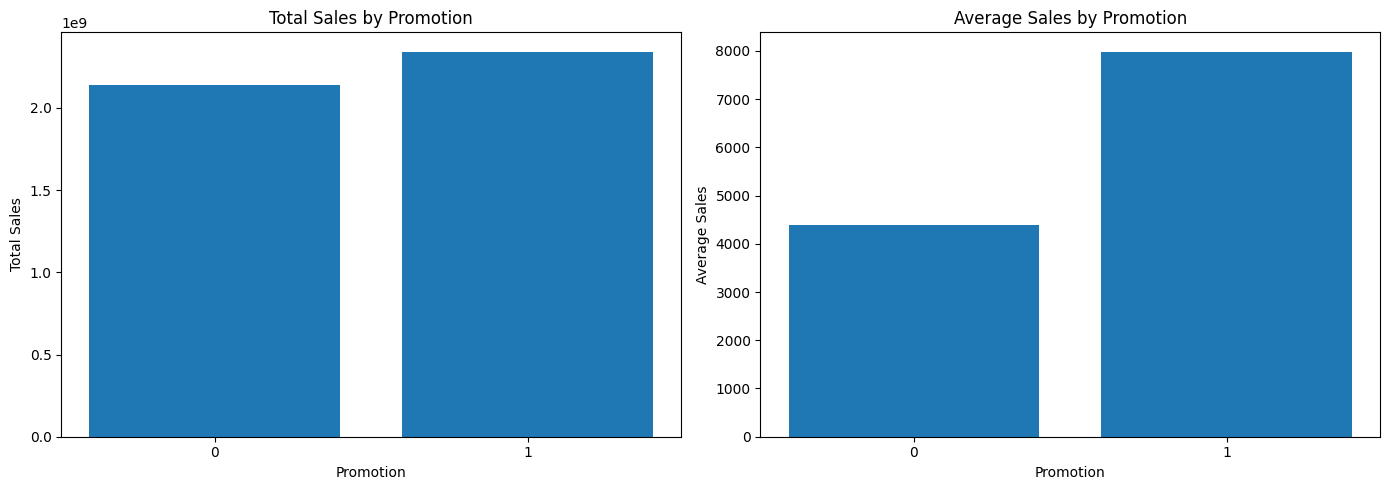

   Promo  Total_Sales  Average_Sales
0      0   2141235943    4392.062633
1      1   2342445037    7986.379492


In [12]:
promo_analysis = df.groupby('Promo')['Sales'].agg(Total_Sales='sum', Average_Sales='mean').reset_index()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# ---------------- Total Sales ----------------
ax[0].bar(
    promo_analysis['Promo'].astype(str),
    promo_analysis['Total_Sales']
)
ax[0].set_title("Total Sales by Promotion")
ax[0].set_xlabel("Promotion")
ax[0].set_ylabel("Total Sales")

# ---------------- Average Sales ----------------
ax[1].bar(
    promo_analysis['Promo'].astype(str),
    promo_analysis['Average_Sales']
)

ax[1].set_title("Average Sales by Promotion")
ax[1].set_xlabel("Promotion")
ax[1].set_ylabel("Average Sales")

plt.tight_layout()
plt.show()

print(promo_analysis)

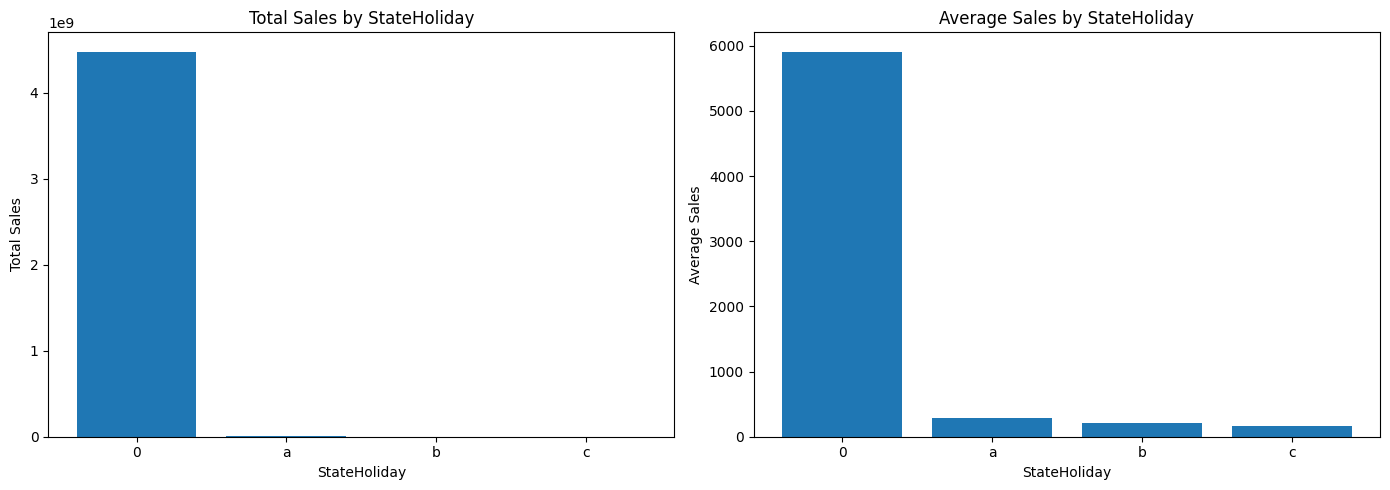

  StateHoliday  Total_Sales  Average_Sales
0            0   4477933800    5911.401332
1            a      4137024     280.267191
2            b       918350     205.908072
3            c       691806     168.733171


In [13]:
StateHoliday_analysis = df.groupby('StateHoliday')['Sales'].agg(Total_Sales='sum', Average_Sales='mean').reset_index()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# ---------------- Total Sales ----------------
ax[0].bar(
    StateHoliday_analysis['StateHoliday'].astype(str),
    StateHoliday_analysis['Total_Sales']
)
ax[0].set_title("Total Sales by StateHoliday")
ax[0].set_xlabel("StateHoliday")
ax[0].set_ylabel("Total Sales")

# ---------------- Average Sales ----------------
ax[1].bar(
    StateHoliday_analysis['StateHoliday'].astype(str),
    StateHoliday_analysis['Average_Sales']
)

ax[1].set_title("Average Sales by StateHoliday")
ax[1].set_xlabel("StateHoliday")
ax[1].set_ylabel("Average Sales")

plt.tight_layout()
plt.show()

print(StateHoliday_analysis)

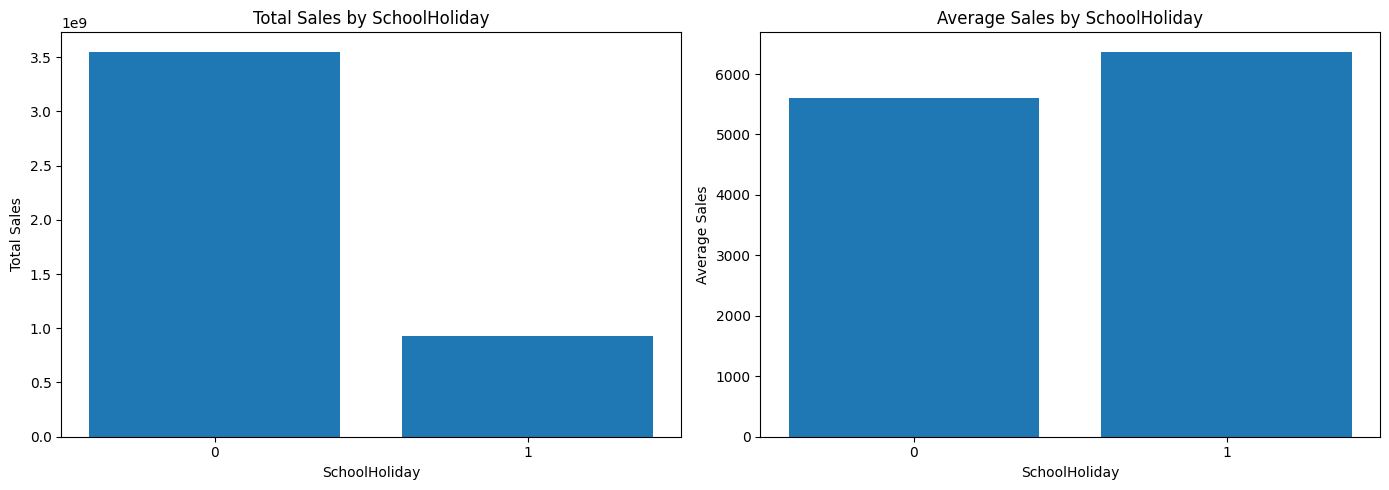

   SchoolHoliday  Total_Sales  Average_Sales
0              0   3550634593    5596.918293
1              1    933046387    6371.613837


In [14]:
SchoolHoliday_analysis = df.groupby('SchoolHoliday')['Sales'].agg(Total_Sales='sum', Average_Sales='mean').reset_index()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# ---------------- Total Sales ----------------
ax[0].bar(
    SchoolHoliday_analysis['SchoolHoliday'].astype(str),
    SchoolHoliday_analysis['Total_Sales']
)
ax[0].set_title("Total Sales by SchoolHoliday")
ax[0].set_xlabel("SchoolHoliday")
ax[0].set_ylabel("Total Sales")

# ---------------- Average Sales ----------------
ax[1].bar(
    SchoolHoliday_analysis['SchoolHoliday'].astype(str),
    SchoolHoliday_analysis['Average_Sales']
)

ax[1].set_title("Average Sales by SchoolHoliday")
ax[1].set_xlabel("SchoolHoliday")
ax[1].set_ylabel("Average Sales")

plt.tight_layout()
plt.show()

print(SchoolHoliday_analysis)

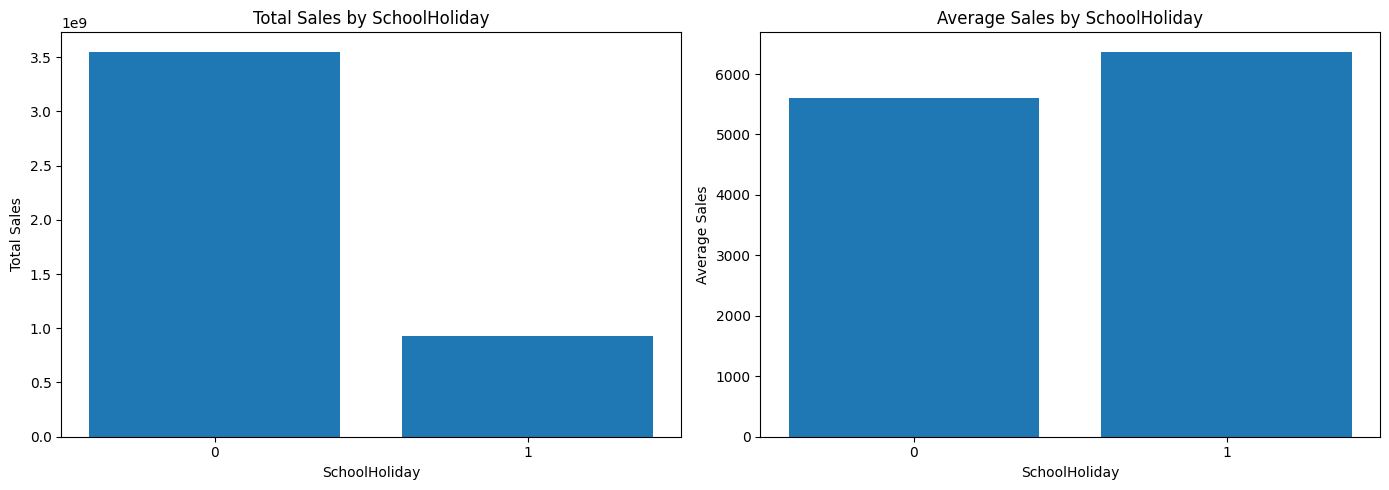

   SchoolHoliday  Total_Sales  Average_Sales
0              0   3550634593    5596.918293
1              1    933046387    6371.613837


In [15]:
SchoolHoliday_analysis = df.groupby('SchoolHoliday')['Sales'].agg(Total_Sales='sum', Average_Sales='mean').reset_index()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# ---------------- Total Sales ----------------
ax[0].bar(
    SchoolHoliday_analysis['SchoolHoliday'].astype(str),
    SchoolHoliday_analysis['Total_Sales']
)
ax[0].set_title("Total Sales by SchoolHoliday")
ax[0].set_xlabel("SchoolHoliday")
ax[0].set_ylabel("Total Sales")

# ---------------- Average Sales ----------------
ax[1].bar(
    SchoolHoliday_analysis['SchoolHoliday'].astype(str),
    SchoolHoliday_analysis['Average_Sales']
)

ax[1].set_title("Average Sales by SchoolHoliday")
ax[1].set_xlabel("SchoolHoliday")
ax[1].set_ylabel("Average Sales")

plt.tight_layout()
plt.show()

print(SchoolHoliday_analysis)

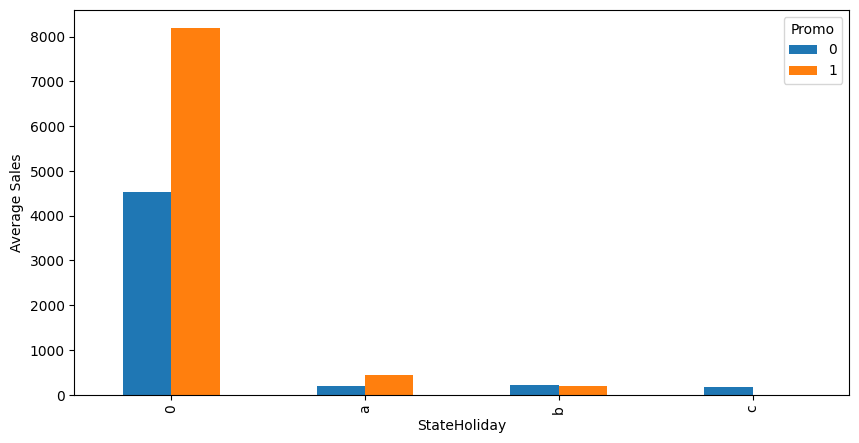

Promo                   0            1
StateHoliday                          
0             4533.188654  8185.938796
a              187.808842   447.222961
b              216.172197   195.643946
c              168.733171          NaN


In [16]:
promo_holiday = pd.pivot_table(
    df,
    values='Sales',
    index='StateHoliday',
    columns='Promo',
    aggfunc='mean'
)

promo_holiday.plot(kind='bar', figsize=(10,5))
plt.ylabel("Average Sales")
plt.show()

print(promo_holiday)

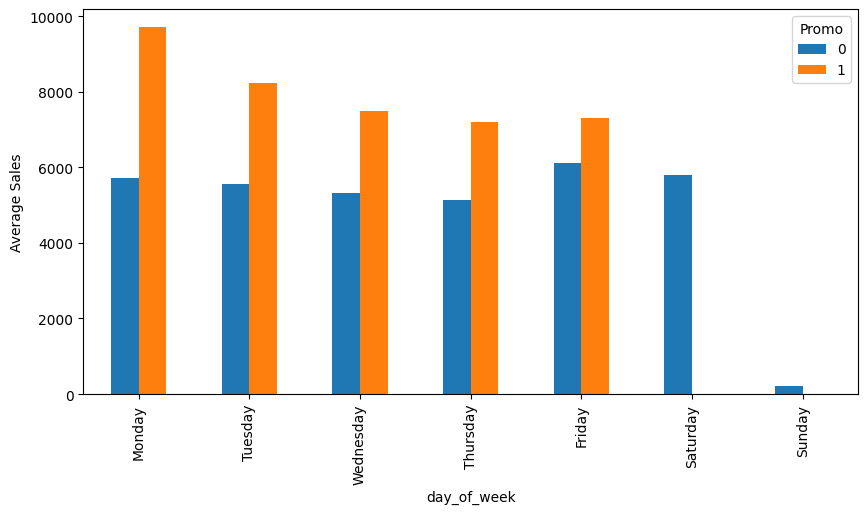

Promo                  0            1
day_of_week                          
Monday       5721.360629  9701.202381
Tuesday      5546.584355  8229.742499
Wednesday    5310.072383  7484.701475
Thursday     5131.363080  7200.941987
Friday       6114.715526  7310.043991
Saturday     5792.947996          NaN
Sunday        201.323994          NaN


In [17]:
df["day_of_week"] = df.index.day_name()

promo_holiday = pd.pivot_table(
    df,
    values='Sales',
    index='day_of_week',
    columns='Promo',
    aggfunc='mean'
)
promo_holiday = promo_holiday.reindex(weekday_order)

promo_holiday.plot(kind='bar', figsize=(10,5))
plt.ylabel("Average Sales")
plt.show()

print(promo_holiday)

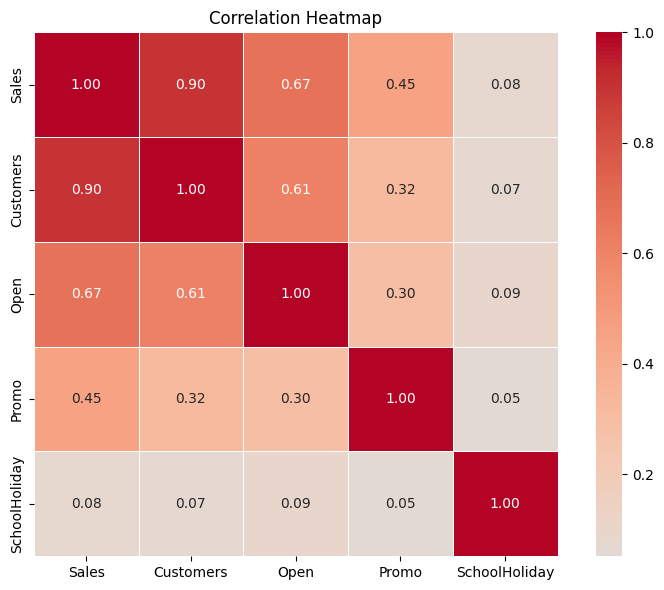

                  Sales  Customers      Open     Promo  SchoolHoliday
Sales          1.000000   0.897413  0.673762  0.451853       0.078498
Customers      0.897413   1.000000  0.614373  0.318008       0.068663
Open           0.673762   0.614373  1.000000  0.295014       0.089858
Promo          0.451853   0.318008  0.295014  1.000000       0.051353
SchoolHoliday  0.078498   0.068663  0.089858  0.051353       1.000000


In [20]:
numeric_cols = ['Sales', 'Customers', 'Open', 
                'Promo', 'SchoolHoliday']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True
)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

print(corr_matrix)